In [16]:
import pandas as pd
import re
from nltk.stem import PorterStemmer
import numpy as np

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
stemmer = PorterStemmer()

hinglish_stopwords = {
    "aap", "aapka", "aapke", "aapki",
    "ab", "abhi",
    "agar",
    "aur",
    "bhi",
    "bas",
    "ek",
    "hai", "hain", "ho",
    "ka", "ke", "ki", "ko",
    "kya",
    "main", "mai", "mein", "me",
    "mera", "mere", "meri",
    "mujhe",
    "na", "nahi", "nahin",
    "par",
    "se",
    "tha", "the", "thi",
    "to",
    "tum", "tumhara", "tumhare", "tumhari",
    "un", "unka", "unke", "unki",
    "us",
    "ye", "yeh",
    "wo", "woh",
    "ya"
}


all_stopwords = set(ENGLISH_STOP_WORDS).union(hinglish_stopwords)

def clean_and_stem(text):

  text = str(text)

  text = text.lower()

  text = re.sub(r'https?://\S+|www\.\S+', '', text)

  text = re.sub(r'\S+@\S+', '', text)

  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

  text = re.sub(r'\s+', ' ', text)

  words = text.split()

  words = [word for word in words if word not in all_stopwords]

  words = [stemmer.stem(word) for word in words]

  return ' '.join(words)

In [18]:
df = pd.read_csv(
    "sms_spam_dataset.tsv",
    sep="\t",
    header=None,
    names=["label", "message"],
)

hinglish_df = pd.read_csv(
    "sms_spam_dataset_1000.tsv",
    sep="\t",
    header=None,
    names=["label", "message"]

)

df = pd.concat([df, hinglish_df], ignore_index=True)

# Remove exact duplicate messages before preprocessing
df = df.drop_duplicates(subset="message").reset_index(drop=True)

# Clean and stem all messages
df["message"] = df["message"].apply(clean_and_stem)

# Remove duplicates created by preprocessing
df = df.drop_duplicates(subset="message").reset_index(drop=True)

print(df.head())
print("\nTotal Messages:", len(df))
print("\nLabel counts:\n", df["label"].value_counts())

  label                                            message
0   ham  jurong point crazi avail bugi n great world la...
1   ham                              ok lar joke wif u oni
2  spam  free entri 2 wkli comp win fa cup final tkt 21...
3   ham                        u dun say earli hor u c say
4   ham                        nah dont think goe usf live

Total Messages: 5092

Label counts:
 label
ham     4465
spam     627
Name: count, dtype: int64


In [19]:
print("Total messages:", len(df))

print("Duplicate messages:", df["message"].duplicated().sum())

print("Duplicate rows:", df.duplicated().sum())



Total messages: 5092
Duplicate messages: 0
Duplicate rows: 0


In [20]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

In [21]:
X = df["message"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4073
Testing messages: 1019


In [22]:
vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Shape of training matrix:", X_train_vec.shape)

Vocabulary size: 5087
Shape of training matrix: (4073, 5087)


In [23]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

print("Model trained!")

Model trained!


In [24]:
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}\n")
print("Classification report:")

print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

Accuracy: 98.43%

Classification report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       894
        spam       0.99      0.88      0.93       125

    accuracy                           0.98      1019
   macro avg       0.99      0.94      0.96      1019
weighted avg       0.98      0.98      0.98      1019



In [25]:
print("Total messages:", len(df))
print("\nLabel counts:")
print(df["label"].value_counts())

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

print("\nTest label counts:")
print(y_test.value_counts())

Total messages: 5092

Label counts:
label
ham     4465
spam     627
Name: count, dtype: int64

Train size: 4073
Test size: 1019

Test label counts:
label_num
0    894
1    125
Name: count, dtype: int64


In [26]:
alphas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

results = []

for alpha in alphas:
    temp_model = MultinomialNB(alpha=alpha)

    temp_model.fit(X_train_vec, y_train)

    temp_pred = temp_model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, temp_pred)

    report = classification_report(
        y_test,
        temp_pred,
        output_dict=True
    )

    # Spam is label 1
    spam_precision = report["1"]["precision"]
    spam_recall = report["1"]["recall"]
    spam_f1 = report["1"]["f1-score"]

    results.append({
        "alpha": alpha,
        "accuracy": accuracy,
        "spam_precision": spam_precision,
        "spam_recall": spam_recall,
        "spam_f1": spam_f1
    })

    print(
        f"alpha={alpha:<4} | "
        f"Accuracy={accuracy:.2%} | "
        f"Spam Precision={spam_precision:.2%} | "
        f"Spam Recall={spam_recall:.2%} | "
        f"Spam F1={spam_f1:.2%}"
    )

alpha=0.01 | Accuracy=97.94% | Spam Precision=95.61% | Spam Recall=87.20% | Spam F1=91.21%
alpha=0.05 | Accuracy=98.04% | Spam Precision=96.46% | Spam Recall=87.20% | Spam F1=91.60%
alpha=0.1  | Accuracy=98.04% | Spam Precision=96.46% | Spam Recall=87.20% | Spam F1=91.60%
alpha=0.2  | Accuracy=98.23% | Spam Precision=96.52% | Spam Recall=88.80% | Spam F1=92.50%
alpha=0.5  | Accuracy=98.43% | Spam Precision=97.39% | Spam Recall=89.60% | Spam F1=93.33%
alpha=1.0  | Accuracy=98.43% | Spam Precision=99.10% | Spam Recall=88.00% | Spam F1=93.22%
alpha=2.0  | Accuracy=98.23% | Spam Precision=99.08% | Spam Recall=86.40% | Spam F1=92.31%
alpha=5.0  | Accuracy=98.04% | Spam Precision=100.00% | Spam Recall=84.00% | Spam F1=91.30%


In [27]:
results_df = pd.DataFrame(results)

print(results_df.round(4))

   alpha  accuracy  spam_precision  spam_recall  spam_f1
0   0.01    0.9794          0.9561        0.872   0.9121
1   0.05    0.9804          0.9646        0.872   0.9160
2   0.10    0.9804          0.9646        0.872   0.9160
3   0.20    0.9823          0.9652        0.888   0.9250
4   0.50    0.9843          0.9739        0.896   0.9333
5   1.00    0.9843          0.9910        0.880   0.9322
6   2.00    0.9823          0.9908        0.864   0.9231
7   5.00    0.9804          1.0000        0.840   0.9130


In [28]:
best_row = results_df.loc[results_df["spam_f1"].idxmax()]

print("Best alpha:", best_row["alpha"])
print("Accuracy:", f"{best_row['accuracy']:.2%}")
print("Spam Precision:", f"{best_row['spam_precision']:.2%}")
print("Spam Recall:", f"{best_row['spam_recall']:.2%}")
print("Spam F1:", f"{best_row['spam_f1']:.2%}")

Best alpha: 0.5
Accuracy: 98.43%
Spam Precision: 97.39%
Spam Recall: 89.60%
Spam F1: 93.33%


In [29]:
best_alpha = 0.5

final_model = MultinomialNB(alpha=best_alpha)

final_model.fit(X_train_vec, y_train)

y_pred_final = final_model.predict(X_test_vec)

final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"Final Accuracy: {final_accuracy:.2%}")

print("\nFinal Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["ham", "spam"]
    )
)

Final Accuracy: 98.43%

Final Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       894
        spam       0.97      0.90      0.93       125

    accuracy                           0.98      1019
   macro avg       0.98      0.95      0.96      1019
weighted avg       0.98      0.98      0.98      1019



In [30]:
spam_probability = final_model.predict_proba(X_test_vec)[:, 1]

In [31]:
thresholds_fine = np.arange(0.20, 0.61, 0.01)

fine_results = []

for threshold in thresholds_fine:

    threshold_pred = (spam_probability >= threshold).astype(int)

    accuracy = accuracy_score(y_test, threshold_pred)

    report = classification_report(
        y_test,
        threshold_pred,
        output_dict=True
    )

    fine_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "spam_precision": report["1"]["precision"],
        "spam_recall": report["1"]["recall"],
        "spam_f1": report["1"]["f1-score"]
    })

fine_df = pd.DataFrame(fine_results)

In [32]:
final_threshold = 0.55

spam_probability = final_model.predict_proba(X_test_vec)[:, 1]

y_pred_threshold = (
    spam_probability >= final_threshold
).astype(int)

print("Final Threshold:", final_threshold)

print(
    f"Accuracy: {accuracy_score(y_test, y_pred_threshold):.2%}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_threshold,
        target_names=["ham", "spam"]
    )
)

Final Threshold: 0.55
Accuracy: 98.53%

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       894
        spam       0.98      0.90      0.94       125

    accuracy                           0.99      1019
   macro avg       0.98      0.95      0.96      1019
weighted avg       0.99      0.99      0.98      1019



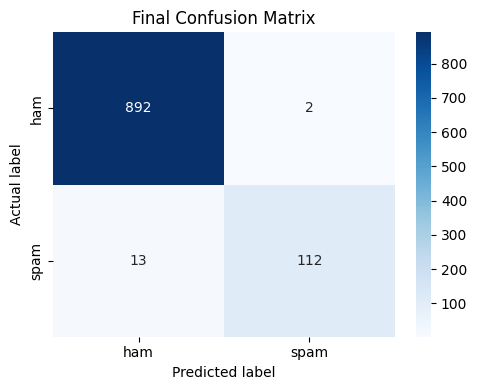

In [33]:
cm = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)

plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Final Confusion Matrix")

plt.tight_layout()
plt.savefig("final_confusion_matrix.png")
plt.show()

In [34]:
# Create a table containing test messages,
# their actual labels, and the model's predictions

errors = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred_final
})

# Find spam messages that the model incorrectly predicted as ham
missed_spam = errors[
    (errors["actual"] == 1) &
    (errors["predicted"] == 0)
]

print("Number of missed spam messages:", len(missed_spam))

print("\nMissed Spam Messages:\n")
print(missed_spam["message"].to_string(index=False))

Number of missed spam messages: 13

Missed Spam Messages:

clair havin borin time u wanna cum 2nite chat 0...
freemsg hi babi wow just got new cam mobi wanna...
    miss alert number call left messag 07008009200
babe u want dont u babi im nasti thing 4 filthy...
tbspersolvo chase sept for38 definit pay thank ...
2 work 2morro half term u c 2nite 4 sexi passio...
interflora late order interflora flower christm...
hi im sue 20 year old work lapdanc love sex tex...
freemsg hey u just got 1 videop fone repli wild...
           sorri miss let talk time im 07090201529
hello darl today love chat dont tell look like ...
block breaker come delux format new featur grea...
romcapspam respond presenc warm outgo bring rea...


In [35]:
def predict_message(text):

    cleaned_text = clean_and_stem(text)

    vec = vectorizer.transform([cleaned_text])

    spam_probability = final_model.predict_proba(vec)[0][1]

    prediction = int(spam_probability >= final_threshold)

    label = "spam" if prediction == 1 else "ham"

    confidence = (
        spam_probability
        if prediction == 1
        else 1 - spam_probability
    )

    return label, confidence


test_messages = [
    #English test
    "Congratulations! You've WON a $1000 Walmart gift card. Click here to claim now!!!",
    "Hey, are we still on for the gym session at 6pm today?",
    "URGENT: Your account has been suspended. Verify your details immediately.",
    "Bro don't forget to bring the charger tomorrow",
    #Hinglish test
     "Aapka account block ho jayega, turant verify karein!",
    "Bhai kal gym 6 baje aa raha hai?",
    "Congratulations aapko free recharge mila hai, claim karne ke liye click karein!"
]

for msg in test_messages:
    label, confidence = predict_message(msg)
    print(f"[{label.upper():5s} | {confidence:.1%}] {msg}")

[SPAM  | 100.0%] Congratulations! You've WON a $1000 Walmart gift card. Click here to claim now!!!
[HAM   | 100.0%] Hey, are we still on for the gym session at 6pm today?
[SPAM  | 99.0%] URGENT: Your account has been suspended. Verify your details immediately.
[HAM   | 100.0%] Bro don't forget to bring the charger tomorrow
[HAM   | 73.9%] Aapka account block ho jayega, turant verify karein!
[HAM   | 98.2%] Bhai kal gym 6 baje aa raha hai?
[SPAM  | 100.0%] Congratulations aapko free recharge mila hai, claim karne ke liye click karein!
